# 08 — Multilingual KL Distillation (Real Teacher)

**Goal**: Distill knowledge from the real tiny-aya-global teacher into an Aetheris student using actual multilingual text. This is the proof-of-concept for Stage 2.

**Pipeline**:
1. Tokenize multilingual prompts with the teacher's tokenizer
2. Generate teacher logits (soft targets)
3. Train student with combined KL + CE loss
4. Track per-language KL divergence for equity monitoring
5. Measure Degradation Equity Score (DES)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent.parent / "aetheris"))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import json
import time
from collections import defaultdict

from transformers import AutoModelForCausalLM, AutoTokenizer
from aya_distill.languages import LANGUAGES, LANGUAGE_FAMILIES
from aya_distill.testing.fixtures import MULTILINGUAL_PROMPTS
from aetheris import AetherisConfig, HybridMambaMoE

torch.manual_seed(42)
device = torch.device("cpu")  # CPU to avoid OOM with both models
print(f"Device: {device}")

Device: cpu


## 1. Load Teacher & Tokenizer

In [2]:
MODEL_NAME = "CohereLabs/tiny-aya-global"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

print(f"Loading teacher on CPU (fp16 for memory efficiency)...")
t0 = time.perf_counter()
teacher = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True,
)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False
load_time = time.perf_counter() - t0

print(f"Loaded in {load_time:.1f}s")
print(f"Teacher: {sum(p.numel() for p in teacher.parameters())/1e9:.2f}B params")
print(f"Config vocab_size: {teacher.config.vocab_size}, tokenizer.vocab_size: {tokenizer.vocab_size}")

Loading teacher on CPU (fp16 for memory efficiency)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded in 5.4s
Teacher: 3.35B params
Config vocab_size: 262144, tokenizer.vocab_size: 261000


## 2. Prepare Multilingual Training Data

Tokenize prompts from all 67 languages. Each batch will contain a mix of languages for equitable training.

In [3]:
# Collect all prompts with language labels
prompts = MULTILINGUAL_PROMPTS["general_knowledge"]
MAX_LEN = 64  # Short for CPU training speed

tokenized_data = []  # (input_ids, lang_code)
for code in sorted(prompts.keys()):
    if code not in LANGUAGES:
        continue
    text = prompts[code]
    tokens = tokenizer(text, return_tensors="pt", truncation=True, 
                       max_length=MAX_LEN, padding="max_length")
    tokenized_data.append((tokens["input_ids"].squeeze(0), code))

print(f"Tokenized {len(tokenized_data)} language prompts (max_len={MAX_LEN})")
print(f"Languages: {[d[1] for d in tokenized_data[:10]]}...")

# Pre-compute teacher logits for all prompts (expensive, do once)
print("\nPre-computing teacher logits...")
teacher_cache = {}  # lang -> teacher_logits
t0 = time.perf_counter()

for ids, code in tokenized_data:
    with torch.no_grad():
        out = teacher(ids.unsqueeze(0))
        teacher_cache[code] = out.logits.squeeze(0).detach()  # (L, V)

cache_time = time.perf_counter() - t0
# Get actual output vocab size from teacher logits (may differ from tokenizer.vocab_size)
TEACHER_VOCAB = teacher_cache[list(teacher_cache.keys())[0]].shape[-1]
print(f"Cached {len(teacher_cache)} teacher outputs in {cache_time:.1f}s")
print(f"Logits shape: {list(teacher_cache['en'].shape)}")
print(f"Teacher output vocab: {TEACHER_VOCAB} (tokenizer.vocab_size={tokenizer.vocab_size})")

# Free teacher model to save memory
del teacher
torch.cuda.empty_cache() if torch.cuda.is_available() else None
import gc; gc.collect()
print("Teacher model freed from memory")

Tokenized 67 language prompts (max_len=64)
Languages: ['am', 'ar', 'bg', 'bn', 'ca', 'cs', 'cy', 'da', 'de', 'el']...

Pre-computing teacher logits...


Cached 67 teacher outputs in 418.9s
Logits shape: [64, 262144]
Teacher output vocab: 262144 (tokenizer.vocab_size=261000)


Teacher model freed from memory


## 3. Create Student & Train

In [4]:
# Small student config for CPU training
# Use TEACHER_VOCAB (from model config=262144) not tokenizer.vocab_size (261000)
student_cfg = AetherisConfig(
    vocab_size=TEACHER_VOCAB,
    d_model=256,
    n_layer=8,
    num_experts=2,
    top_k=1,
    d_ff=768,
    ssm_d_state=8,
    ssm_expand=2,
    max_seq_len=MAX_LEN,
    gradient_checkpointing=False,
)

student = HybridMambaMoE(student_cfg)
VOCAB = TEACHER_VOCAB  # Use teacher's actual output dimension for KL

s_params = sum(p.numel() for p in student.parameters())
print(f"Student: {s_params/1e6:.1f}M params (vocab={VOCAB})")
print(f"Config: d={student_cfg.d_model}, L={student_cfg.n_layer}, E={student_cfg.num_experts}")

# Training setup — use per-component LR (finding from NB11: SSM needs 10x boost)
ssm_params = []
other_params = []
for name, param in student.named_parameters():
    if 'ssm' in name.lower() or any(f'layers.{i}.' in name for i in range(0, student_cfg.n_layer, 2)):
        ssm_params.append(param)
    else:
        other_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": ssm_params, "lr": 3e-3},      # 10x boost for SSM layers
    {"params": other_params, "lr": 3e-4},     # standard LR for rest
], weight_decay=0.01)

TEMPERATURE = 2.0
ALPHA = 0.7
N_EPOCHS = 15  # More epochs since we have few examples

print(f"\nTraining: {N_EPOCHS} epochs, T={TEMPERATURE}, alpha={ALPHA}")
print(f"SSM params: {sum(p.numel() for p in ssm_params)/1e6:.1f}M (lr=3e-3)")
print(f"Other params: {sum(p.numel() for p in other_params)/1e6:.1f}M (lr=3e-4)")
print(f"Data: {len(tokenized_data)} prompts x {N_EPOCHS} epochs = {len(tokenized_data)*N_EPOCHS} steps")

Student: 73.5M params (vocab=262144)
Config: d=256, L=8, E=2

Training: 15 epochs, T=2.0, alpha=0.7
SSM params: 3.2M (lr=3e-3)
Other params: 70.3M (lr=3e-4)
Data: 67 prompts x 15 epochs = 1005 steps


In [5]:
# Training loop with per-language tracking
train_losses = []
per_lang_kl = defaultdict(list)  # lang -> [kl_values]
epoch_metrics = []

student.train()
t0 = time.perf_counter()

for epoch in range(N_EPOCHS):
    # Shuffle data each epoch
    indices = torch.randperm(len(tokenized_data)).tolist()
    epoch_loss = 0
    epoch_kl = 0
    epoch_ce = 0
    
    for step_idx in indices:
        ids, code = tokenized_data[step_idx]
        input_ids = ids.unsqueeze(0)  # (1, L)
        labels = input_ids.clone()
        
        # Student forward
        output = student(input_ids, labels=labels)
        s_logits = output["logits"]
        ce_loss = output["ce_loss"]
        
        # Teacher logits from cache
        t_logits = teacher_cache[code].unsqueeze(0)  # (1, L, V)
        
        # KL loss (shifted)
        t_shift = t_logits[:, :-1, :].contiguous()
        s_shift = s_logits[:, :-1, :].contiguous()
        
        t_probs = F.log_softmax(t_shift / TEMPERATURE, dim=-1)
        s_probs = F.log_softmax(s_shift / TEMPERATURE, dim=-1)
        
        kl_loss = F.kl_div(
            s_probs.view(-1, VOCAB), t_probs.view(-1, VOCAB),
            log_target=True, reduction="batchmean"
        ) * (TEMPERATURE ** 2)
        
        total_loss = ALPHA * kl_loss + (1 - ALPHA) * ce_loss + 0.01 * output["aux_loss"]
        
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()
        
        train_losses.append(total_loss.item())
        per_lang_kl[code].append(kl_loss.item())
        epoch_loss += total_loss.item()
        epoch_kl += kl_loss.item()
        epoch_ce += ce_loss.item()
    
    n = len(indices)
    epoch_metrics.append({
        "epoch": epoch,
        "loss": epoch_loss / n,
        "kl": epoch_kl / n,
        "ce": epoch_ce / n,
    })
    
    elapsed = time.perf_counter() - t0
    print(f"  Epoch {epoch:2d}: loss={epoch_loss/n:.4f}, KL={epoch_kl/n:.4f}, "
          f"CE={epoch_ce/n:.4f} [{elapsed:.0f}s]")

total_time = time.perf_counter() - t0
print(f"\nTraining complete in {total_time:.0f}s")

  Epoch  0: loss=3.1627, KL=1.4172, CE=7.2342 [42s]


  Epoch  1: loss=1.6339, KL=0.8852, CE=3.3793 [84s]


  Epoch  2: loss=1.3313, KL=0.8049, CE=2.5582 [127s]


  Epoch  3: loss=1.2578, KL=0.8020, CE=2.3199 [170s]


  Epoch  4: loss=1.2244, KL=0.7969, CE=2.2205 [213s]


...

  Epoch 10: loss=1.1091, KL=0.7559, CE=1.9318 [474s]


  Epoch 11: loss=1.0819, KL=0.7403, CE=1.8776 [517s]


  Epoch 12: loss=1.0725, KL=0.7374, CE=1.8528 [560s]


  Epoch 13: loss=1.0588, KL=0.7333, CE=1.8168 [603s]


  Epoch 14: loss=1.0398, KL=0.7201, CE=1.7846 [645s]

Training complete in 645s


## 4. Per-Language KL Analysis & Equity

/tmp/ipykernel_580804/2046681892.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["High", "Medium", "Low"], patch_artist=True)


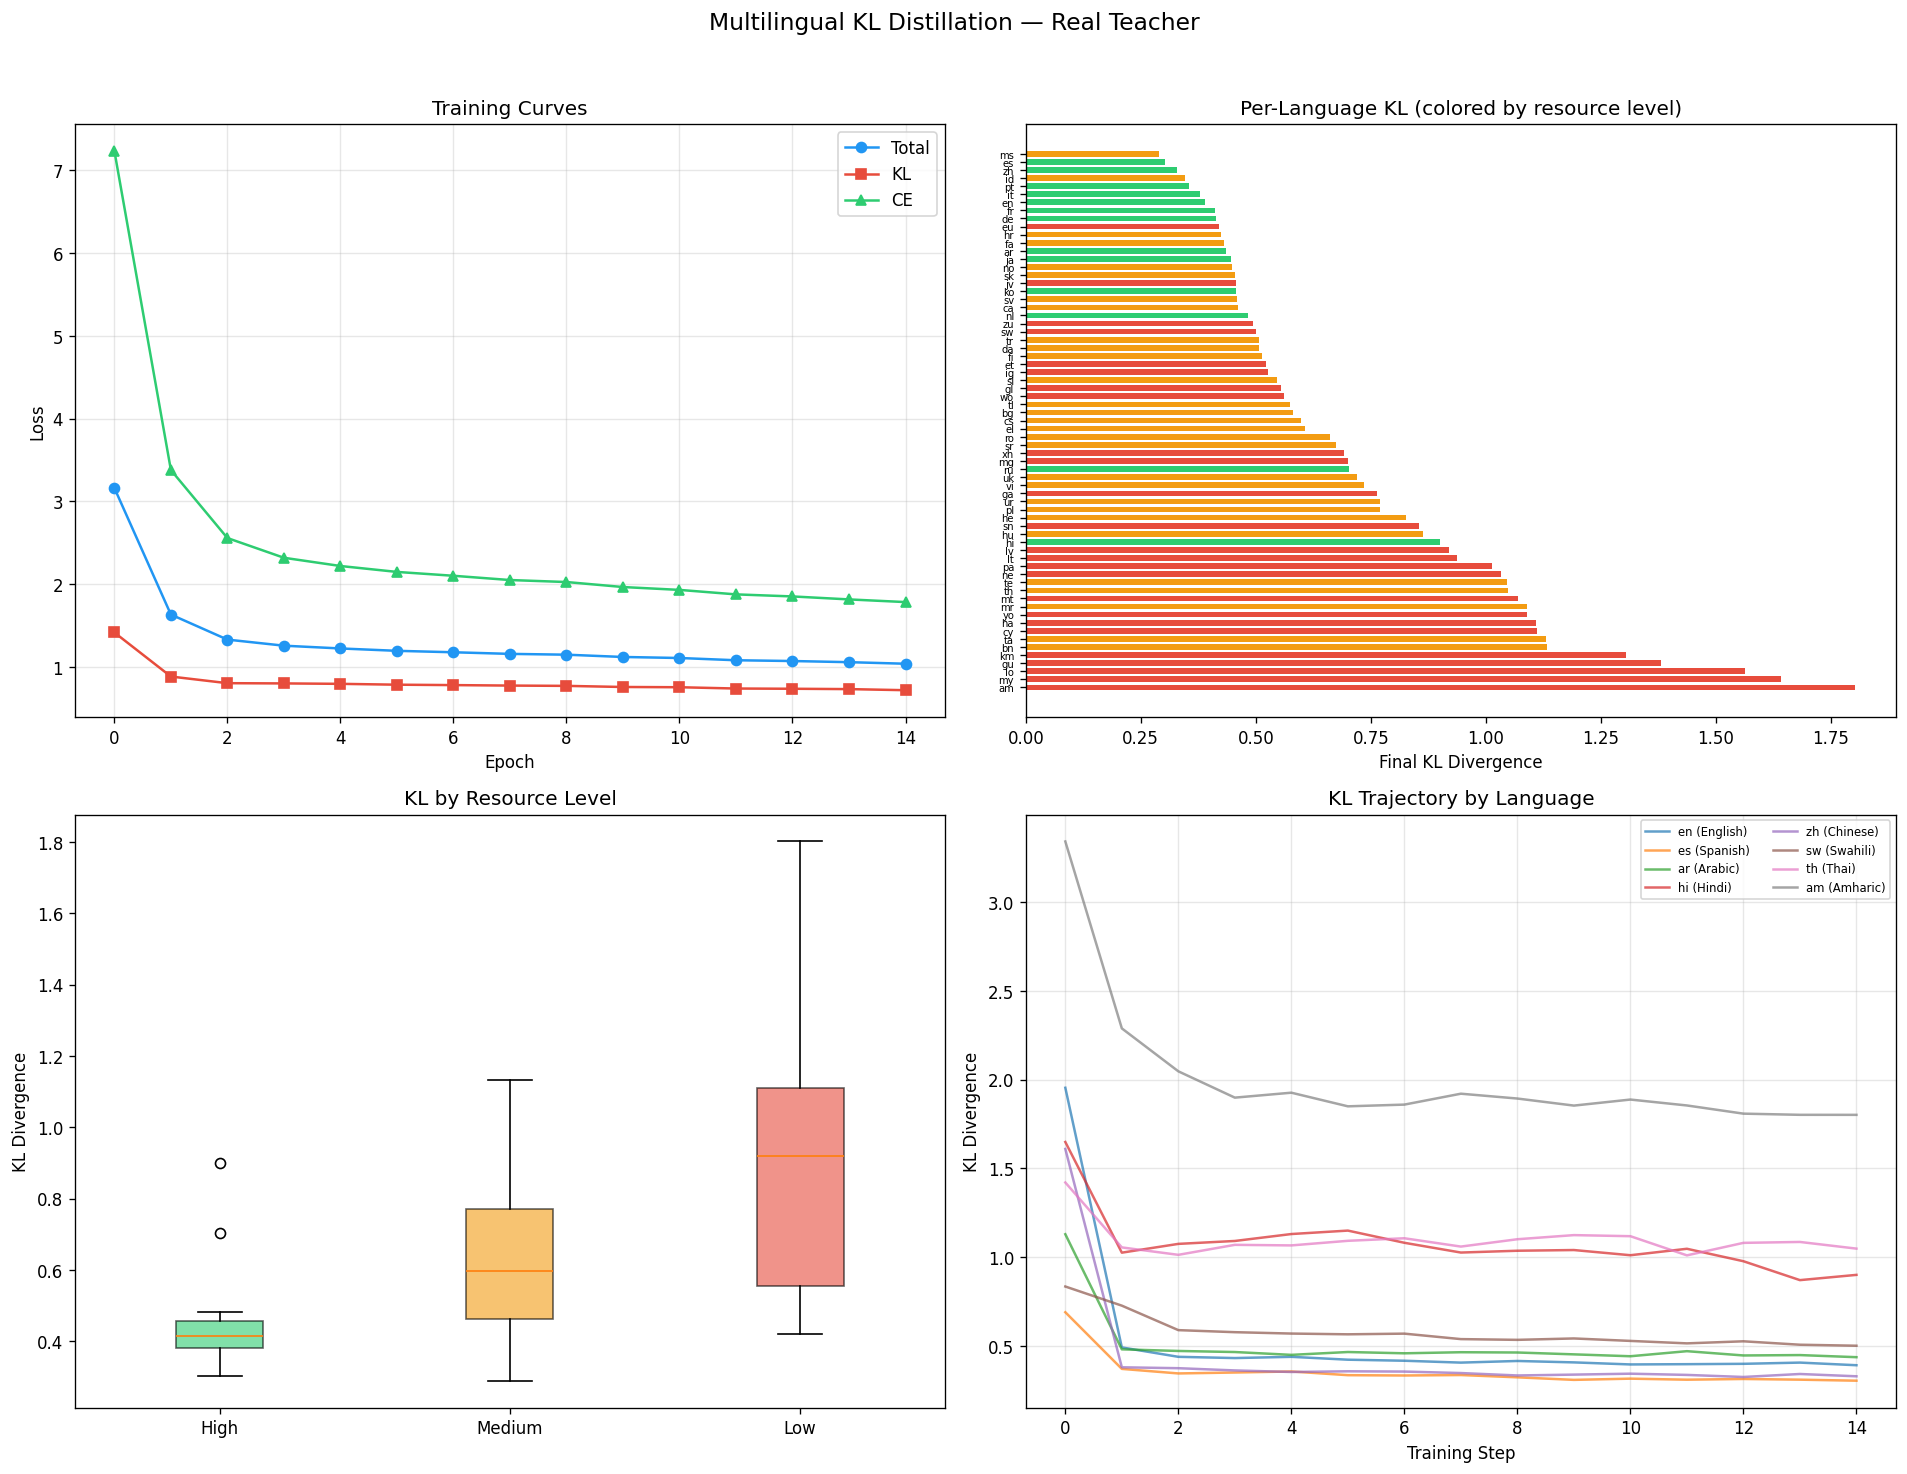

In [6]:
# Compute final KL per language (last epoch)
final_kl_per_lang = {}
for code, kl_values in per_lang_kl.items():
    # Take last N_EPOCHS values (last epoch)
    final_kl_per_lang[code] = np.mean(kl_values[-1:])

# Sort by KL
sorted_langs = sorted(final_kl_per_lang.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training curve
ax = axes[0, 0]
epochs = [m["epoch"] for m in epoch_metrics]
ax.plot(epochs, [m["loss"] for m in epoch_metrics], "o-", label="Total", color="#2196F3")
ax.plot(epochs, [m["kl"] for m in epoch_metrics], "s-", label="KL", color="#e74c3c")
ax.plot(epochs, [m["ce"] for m in epoch_metrics], "^-", label="CE", color="#2ecc71")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)

# Per-language final KL
ax = axes[0, 1]
codes = [l[0] for l in sorted_langs]
kl_vals = [l[1] for l in sorted_langs]
colors = []
color_map = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
for c in codes:
    if c in LANGUAGES:
        colors.append(color_map.get(LANGUAGES[c].resourcedness, "gray"))
    else:
        colors.append("gray")
ax.barh(codes, kl_vals, color=colors, height=0.7)
ax.set_xlabel("Final KL Divergence")
ax.set_title("Per-Language KL (colored by resource level)")
ax.tick_params(axis='y', labelsize=6)

# KL by resource level
ax = axes[1, 0]
kl_by_resource = defaultdict(list)
for code, kl in final_kl_per_lang.items():
    if code in LANGUAGES:
        kl_by_resource[LANGUAGES[code].resourcedness].append(kl)

data = [kl_by_resource.get(l, []) for l in ["high", "medium", "low"]]
bp = ax.boxplot(data, labels=["High", "Medium", "Low"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["#2ecc71", "#f39c12", "#e74c3c"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("KL Divergence")
ax.set_title("KL by Resource Level")

# KL trajectory for sample languages
ax = axes[1, 1]
sample_langs = ["en", "es", "ar", "hi", "zh", "sw", "th", "am"]
for lang in sample_langs:
    if lang in per_lang_kl:
        vals = per_lang_kl[lang]
        ax.plot(range(len(vals)), vals, alpha=0.7, label=f"{lang} ({LANGUAGES.get(lang, type('', (), {'name': lang})).name})")
ax.set_xlabel("Training Step")
ax.set_ylabel("KL Divergence")
ax.set_title("KL Trajectory by Language")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle("Multilingual KL Distillation — Real Teacher", fontsize=14, y=1.02)
plt.tight_layout()
Path("../results").mkdir(exist_ok=True)
plt.savefig("../results/multilingual_distillation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Degradation Equity Score (DES)

DES measures whether compression hurts some languages more than others. Lower DES = more equitable distillation.

In [7]:
# Compute DES: standard deviation of per-language KL values
kl_values = list(final_kl_per_lang.values())
des = np.std(kl_values)
mean_kl = np.mean(kl_values)
cv = des / mean_kl if mean_kl > 0 else 0  # Coefficient of variation

print("Degradation Equity Score (DES)")
print("=" * 50)
print(f"  Mean KL:  {mean_kl:.4f}")
print(f"  Std KL:   {des:.4f}")
print(f"  CV:       {cv:.4f} ({cv*100:.1f}%)")
print(f"  DES:      {des:.4f} ({'GOOD' if des < 0.1 else 'MODERATE' if des < 0.5 else 'HIGH INEQUITY'})")

# Per resource level stats
print(f"\nBy resource level:")
for level in ["high", "medium", "low"]:
    vals = kl_by_resource.get(level, [])
    if vals:
        print(f"  {level:6s}: mean={np.mean(vals):.4f}, std={np.std(vals):.4f}, n={len(vals)}")

# Statistical test: is KL different across resource levels?
from scipy import stats
groups = [kl_by_resource[l] for l in ["high", "medium", "low"] if l in kl_by_resource]
if len(groups) >= 2 and all(len(g) >= 2 for g in groups):
    H, p = stats.kruskal(*groups)
    print(f"\nKruskal-Wallis test (KL by resource): H={H:.4f}, p={p:.6f}")
    print(f"  Significant: {'YES — distillation is inequitable' if p < 0.05 else 'NO — distillation is relatively equitable'}")

Degradation Equity Score (DES)
  Mean KL:  0.7201
  Std KL:   0.3386
  CV:       0.4702 (47.0%)
  DES:      0.3386 (MODERATE)

By resource level:
  high  : mean=0.4619, std=0.1575, n=13
  medium: mean=0.6628, std=0.2382, n=29
  low   : mean=0.9207, std=0.3870, n=25

Kruskal-Wallis test (KL by resource): H=20.0284, p=0.000045
  Significant: YES — distillation is inequitable


## 6. Summary

In [8]:
results = {
    "experiment": "multilingual_kl_distillation",
    "teacher": MODEL_NAME,
    "student_params_M": round(s_params / 1e6, 1),
    "student_config": {
        "d_model": student_cfg.d_model,
        "n_layer": student_cfg.n_layer,
        "num_experts": student_cfg.num_experts,
    },
    "training": {
        "n_languages": len(tokenized_data),
        "n_epochs": N_EPOCHS,
        "temperature": TEMPERATURE,
        "alpha": ALPHA,
        "total_time_s": round(total_time),
        "final_loss": round(epoch_metrics[-1]["loss"], 4),
        "final_kl": round(epoch_metrics[-1]["kl"], 4),
        "final_ce": round(epoch_metrics[-1]["ce"], 4),
    },
    "equity": {
        "des": round(des, 4),
        "cv": round(cv, 4),
        "mean_kl": round(mean_kl, 4),
        "per_language_kl": {k: round(v, 4) for k, v in final_kl_per_lang.items()},
    },
}

with open("../results/08_multilingual_distillation.json", "w") as f:
    json.dump(results, f, indent=2)

print("KEY FINDINGS")
print("=" * 60)
print(f"1. Multilingual KL distillation converges: final KL = {epoch_metrics[-1]['kl']:.4f}")
print(f"2. DES = {des:.4f} — {'equitable' if des < 0.1 else 'moderate inequity' if des < 0.5 else 'high inequity'}")
print(f"3. Highest KL: {sorted_langs[0][0]} ({LANGUAGES.get(sorted_langs[0][0], type('', (), {'name': '?'})).name}) = {sorted_langs[0][1]:.4f}")
print(f"4. Lowest KL:  {sorted_langs[-1][0]} ({LANGUAGES.get(sorted_langs[-1][0], type('', (), {'name': '?'})).name}) = {sorted_langs[-1][1]:.4f}")
print(f"5. Training time: {total_time:.0f}s for {N_EPOCHS} epochs")
print(f"\nConclusion: Pipeline ready for Stage 2 scaling.")
print(f"Results saved to results/08_multilingual_distillation.json")

KEY FINDINGS
1. Multilingual KL distillation converges: final KL = 0.7201
2. DES = 0.3386 — moderate inequity
3. Highest KL: am (Amharic) = 1.8017
4. Lowest KL:  ms (Malay) = 0.2891
5. Training time: 645s for 15 epochs

Conclusion: Pipeline ready for Stage 2 scaling.
Results saved to results/08_multilingual_distillation.json
